<a href="https://colab.research.google.com/github/ridmikaw/ML-Assignment-Logistic-Regression/blob/main/IT22088246.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Card Fraud Detection using Logistic Regression
**IT Number - IT22088246**

**Assignment - Supervised Machine Learning**  
**Algorithm: Logistic Regression**  
**Dataset: Credit Card Fraud Detection (284,808 records)**

---
## 📚 Step 1: Import Libraries

In [11]:
# ── Data manipulation ────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn           as sns

# ── Preprocessing ────────────────────────────────────────────
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score

# ── Handling class imbalance ─────────────────────────────────
from imblearn.over_sampling  import SMOTE
from collections             import Counter

# ── Logistic Regression model ────────────────────────────────
from sklearn.linear_model    import LogisticRegression

# ── Evaluation metrics ───────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)

# ── Install imbalanced-learn (for SMOTE) ─────────────────────
!pip install -q imbalanced-learn

# ── Reproducibility seed ─────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 6)})

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


---
## 📦 Step 2: Dataset Description & Load from Google Drive

### About the Dataset
| Property | Detail |
|---|---|
| **Source** | [Kaggle – Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) |
| **Provider** | ULB Machine Learning Group, Belgium |
| **Records** | 284,808 transactions |
| **Features** | 30 (28 PCA components + Time + Amount) |
| **Target** | `Class` → 0 = Legitimate, 1 = Fraud |
| **Fraud ratio** | ~0.17 % (492 fraudulent out of 284,807) |
| **Time span** | 2 days of European card-holder transactions (Sept 2013) |
| **Storage** | Loaded directly from Google Drive |

**Feature notes:**
- **V1–V28**: Principal components obtained via PCA (original features are anonymised for confidentiality)
- **Time**: Seconds elapsed since the first transaction in the dataset
- **Amount**: Transaction amount in EUR
- **Class**: Binary target label (0 = Legitimate, 1 = Fraud)

In [12]:
from google.colab import drive

# ── Mount Google Drive ──────────────────────────────────
drive.mount('/content/drive')
print("✅ Google Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive


In [13]:
import os

# directly in My Drive root
DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/ml-assignment/creditcard.csv'

# ── Verify the file exists before loading ───────────────────
if os.path.exists(DATASET_PATH):
    file_size_mb = os.path.getsize(DATASET_PATH) / (1024 * 1024)
    print(f"✅ Found: {DATASET_PATH}")
    print(f"   File size: {file_size_mb:.1f} MB")
else:
    # If not found, search Drive automatically
    print("⚠️  File not found at default path. Searching Drive...")
    result = !find /content/drive/MyDrive -name 'creditcard.csv' 2>/dev/null
    if result:
        DATASET_PATH = result[0]
        print(f"✅ Auto-found at: {DATASET_PATH}")
        print(f"   Update DATASET_PATH above to this path for next run.")
    else:
        print("❌ creditcard.csv not found in Google Drive.")
        print("   Please upload it to your Drive and update DATASET_PATH.")

✅ Found: /content/drive/MyDrive/Colab Notebooks/ml-assignment/creditcard.csv
   File size: 143.8 MB


In [14]:
# ── Load CSV into a Pandas DataFrame ───────────────────
print("Loading dataset from Google Drive...")
df = pd.read_csv(DATASET_PATH)

print(f"\n✅ Dataset loaded successfully!")
print(f"   Shape         : {df.shape}")
print(f"   Total records : {len(df):,}")
print(f"   Total columns : {df.shape[1]}")
print(f"\nColumn names:")
print(list(df.columns))
print("\nFirst 5 rows:")
df.head()

Loading dataset from Google Drive...

✅ Dataset loaded successfully!
   Shape         : (284807, 31)
   Total records : 284,807
   Total columns : 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic statistics ────────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")
print("\nDescriptive statistics (Amount & Time):")
df[['Time','Amount']].describe()

DATASET OVERVIEW
Rows    : 284,807
Columns : 31

Data types:
float64    30
int64       1
Name: count, dtype: int64

Missing values:
0 total

Descriptive statistics (Amount & Time):


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


---
## ⚙️ Step 4: Data Preprocessing

In [ ]:
# ── Check for missing values ───────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found")

Missing values per column:
✅ No missing values found


In [ ]:
# ── Feature Scaling ────────────────────────────────────

scaler = StandardScaler()

df_processed = df.copy()
df_processed['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df_processed['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df_processed.drop(columns=['Amount', 'Time'], inplace=True)

print("✅ StandardScaler applied to 'Amount' and 'Time'")
print(f"Amount_scaled → mean: {df_processed['Amount_scaled'].mean():.4f}, "
      f"std: {df_processed['Amount_scaled'].std():.4f}")
print(f"Time_scaled   → mean: {df_processed['Time_scaled'].mean():.4f},   "
      f"std: {df_processed['Time_scaled'].std():.4f}")

✅ StandardScaler applied to 'Amount' and 'Time'
Amount_scaled → mean: 0.0000, std: 1.0000
Time_scaled   → mean: -0.0000,   std: 1.0000


In [ ]:
# ── Train / Test Split ─────────────────────────────────

X = df_processed.drop(columns=['Class'])   # feature matrix  (30 columns)
y = df_processed['Class']                  # target vector   (0 / 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,           # 80% train, 20% test
    random_state = RANDOM_STATE,
    stratify     = y               # keep class ratio identical in both splits
)

print("Train/Test Split (stratified):")
print(f"  Training set   : {len(X_train):,} samples")
print(f"  Test set       : {len(X_test):,} samples")
print(f"  Fraud in train : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"  Fraud in test  : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

Train/Test Split (stratified):
  Training set   : 227,845 samples
  Test set       : 56,962 samples
  Fraud in train : 394 (0.173%)
  Fraud in test  : 98  (0.172%)


Class distribution BEFORE SMOTE (training set):
Counter({0: 227451, 1: 394})

Class distribution AFTER SMOTE (training set):
Counter({0: 227451, 1: 227451})

✅ Training set expanded from 227,845 → 454,902 samples
   Classes are now perfectly balanced for training


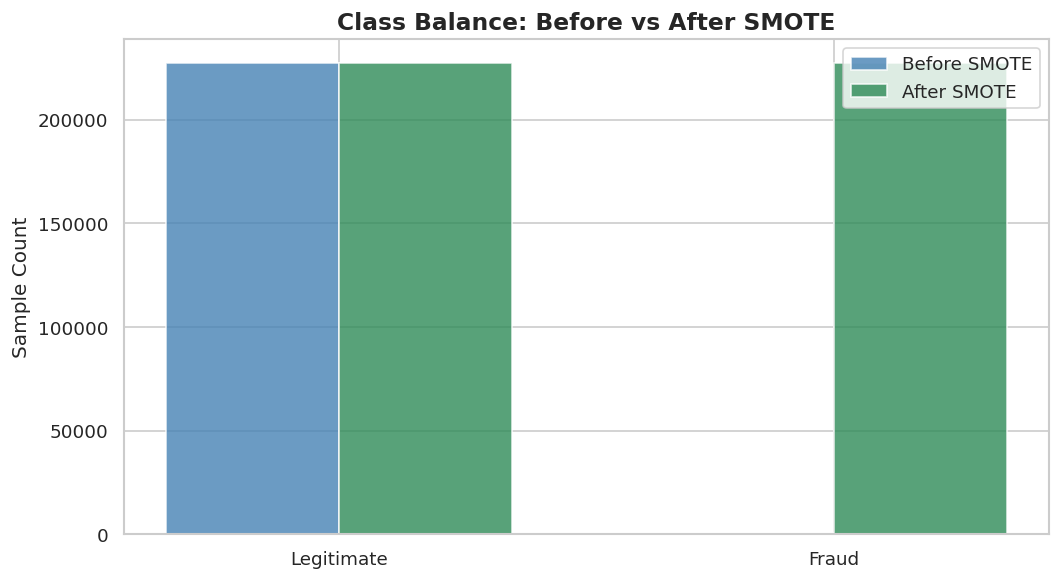

In [ ]:
# ── 5.4  Handle Class Imbalance with SMOTE ──────────────────
# SMOTE (Synthetic Minority Over-sampling Technique)

print("Class distribution BEFORE SMOTE (training set):")
print(Counter(y_train))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE (training set):")
print(Counter(y_train_sm))
print(f"\n✅ Training set expanded from {len(X_train):,} → {len(X_train_sm):,} samples")
print("   Classes are now perfectly balanced for training")

# ── Visualise SMOTE effect ───────────────────────────────────
labels  = ['Legitimate', 'Fraud']
before  = [Counter(y_train)[0], Counter(y_train)[1]]
after   = [Counter(y_train_sm)[0], Counter(y_train_sm)[1]]
x       = np.arange(len(labels))
width   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, before, width, label='Before SMOTE', color='steelblue', alpha=0.8)
ax.bar(x + width/2, after,  width, label='After SMOTE',  color='seagreen',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Class Balance: Before vs After SMOTE', fontsize=14, fontweight='bold')
ax.set_ylabel('Sample Count')
ax.legend()
plt.tight_layout()
plt.savefig("smote_balance.png", bbox_inches='tight')
plt.show()

---
## 🧠 Step 5: Algorithm Introduction – Logistic Regression

### What is Logistic Regression?
Logistic Regression is a **supervised binary classification** algorithm that models the probability of a binary outcome using the **sigmoid (logistic) function**.

$$P(y=1 | X) = \sigma(w^T X + b) = \frac{1}{1 + e^{-(w^T X + b)}}$$

### Why Logistic Regression for Fraud Detection?
| Reason | Explanation |
|---|---|
| **Interpretability** | Coefficients directly show feature importance |
| **Probability output** | Returns P(fraud) rather than just a label |
| **Efficiency** | Scales to 284,808 records in seconds |
| **Baseline standard** | Industry-accepted benchmark for fraud models |
| **Regularisation** | L1/L2 prevent overfitting on high-dim PCA features |

### Cost Function (Binary Cross-Entropy / Log Loss)
$$J(w) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Training minimises $J(w)$ via gradient descent with L2 regularisation (Ridge).

In [15]:
# ============================================================
# LOGISTIC REGRESSION MODEL TRAINING
# Here train three variants to compare:
#   (a) Baseline   – no class-weight adjustment
#   (b) Weighted   – class_weight='balanced'
#   (c) SMOTE      – trained on SMOTE-resampled data
# ============================================================

# ── Baseline model ─────────────────────────────────────
lr_baseline = LogisticRegression(
    max_iter     = 1000,            # enough iterations to converge
    solver       = 'lbfgs',         # efficient for medium-large datasets
    C            = 1.0,             # inverse of regularisation strength
    random_state = RANDOM_STATE
)
lr_baseline.fit(X_train, y_train)
print("✅ Baseline Logistic Regression trained")

# ── Class-weighted model ───────────────────────────────
# class_weight='balanced' auto-adjusts weights inversely
# proportional to class frequency: w_j = n / (k * n_j)
lr_weighted = LogisticRegression(
    max_iter     = 1000,
    solver       = 'lbfgs',
    C            = 1.0,
    class_weight = 'balanced',      # penalise fraud misclassification more
    random_state = RANDOM_STATE
)
lr_weighted.fit(X_train, y_train)
print("✅ Weighted Logistic Regression trained")

# ── SMOTE-trained model (primary model) ────────────────
lr_smote = LogisticRegression(
    max_iter     = 1000,
    solver       = 'lbfgs',
    C            = 1.0,
    random_state = RANDOM_STATE
)
lr_smote.fit(X_train_sm, y_train_sm)   # trained on balanced SMOTE dataset
print("✅ SMOTE-based Logistic Regression trained")


✅ Baseline Logistic Regression trained
✅ Weighted Logistic Regression trained
✅ SMOTE-based Logistic Regression trained


---
## 📊 Step 6: Model Evaluation & Results

In [16]:
# ============================================================
# MODEL EVALUATION
# For imbalanced fraud detection, NEVER rely on accuracy alone.
# Key metrics: Precision, Recall, F1, ROC-AUC, PR-AUC
#
# In fraud detection:
#   • High Recall  → catch most fraud (fewer false negatives)
#   • High Precision → fewer false alarms (fewer false positives)
# ============================================================

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Compute and print all key classification metrics."""
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]   # P(fraud)

    acc         = accuracy_score(y_test, y_pred)
    prec        = precision_score(y_test, y_pred, zero_division=0)
    rec         = recall_score(y_test, y_pred)
    f1          = f1_score(y_test, y_pred)
    roc_auc     = roc_auc_score(y_test, y_prob)
    pr_auc      = average_precision_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision         : {prec:.4f}")
    print(f"  Recall            : {rec:.4f}")
    print(f"  F1-Score          : {f1:.4f}")
    print(f"  ROC-AUC           : {roc_auc:.4f}")
    print(f"  PR-AUC            : {pr_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraud']))

    return {
        'name': model_name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }

# ── Evaluate all three models ────────────────────────────────
res_baseline = evaluate_model(lr_baseline, X_test, y_test, "Baseline Logistic Regression")
res_weighted = evaluate_model(lr_weighted, X_test, y_test, "Weighted Logistic Regression")
res_smote    = evaluate_model(lr_smote,    X_test, y_test, "SMOTE Logistic Regression")


  Baseline Logistic Regression
  Accuracy          : 0.9992
  Precision         : 0.8289
  Recall            : 0.6429
  F1-Score          : 0.7241
  ROC-AUC           : 0.9573
  PR-AUC            : 0.7439

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


  Weighted Logistic Regression
  Accuracy          : 0.9755
  Precision         : 0.0609
  Recall            : 0.9184
  F1-Score          : 0.1141
  ROC-AUC           : 0.9722
  PR-AUC            : 0.7189

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98  

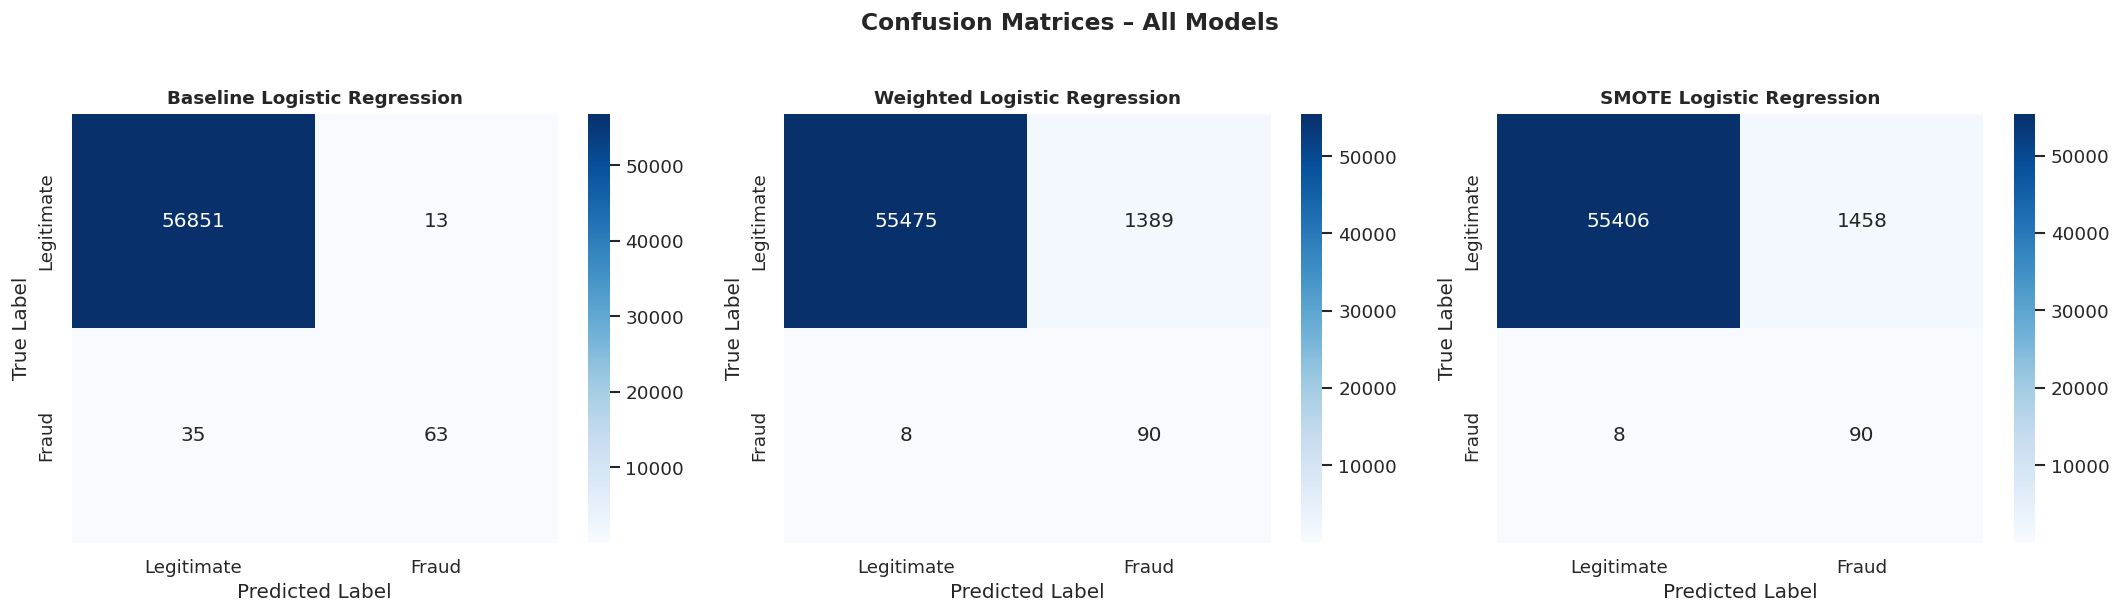

In [17]:
# ── Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results   = [res_baseline, res_weighted, res_smote]

for ax, res in zip(axes, results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate','Fraud'],
                yticklabels=['Legitimate','Fraud'])
    ax.set_title(res['name'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches='tight')
plt.show()

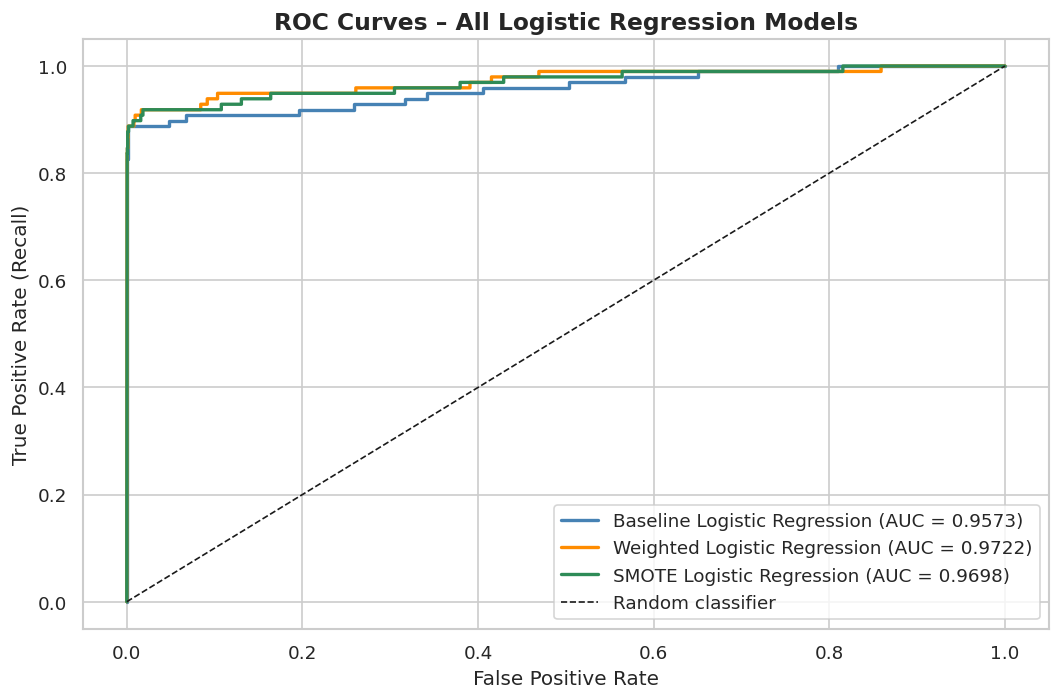

In [18]:
# ── ROC Curves ─────────────────────────────────────────
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'seagreen']

for res, col in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=col, lw=2,
             label=f"{res['name']} (AUC = {res['roc_auc']:.4f})")

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves – All Logistic Regression Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches='tight')
plt.show()

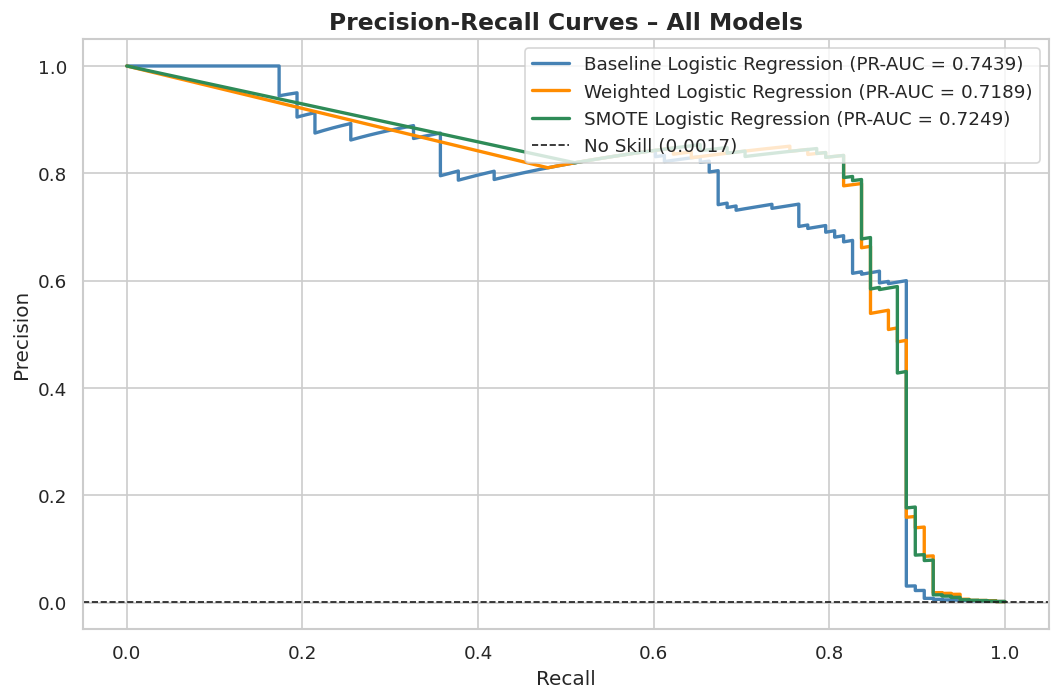

In [19]:
# ── Precision-Recall Curves ────────────────────────────

plt.figure(figsize=(9, 6))
for res, col in zip(results, colors):
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_prob'])
    plt.plot(rec_c, prec_c, color=col, lw=2,
             label=f"{res['name']} (PR-AUC = {res['pr_auc']:.4f})")

no_skill = y_test.sum() / len(y_test)
plt.axhline(y=no_skill, color='k', linestyle='--', lw=1, label=f'No Skill ({no_skill:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("pr_curves.png", bbox_inches='tight')
plt.show()

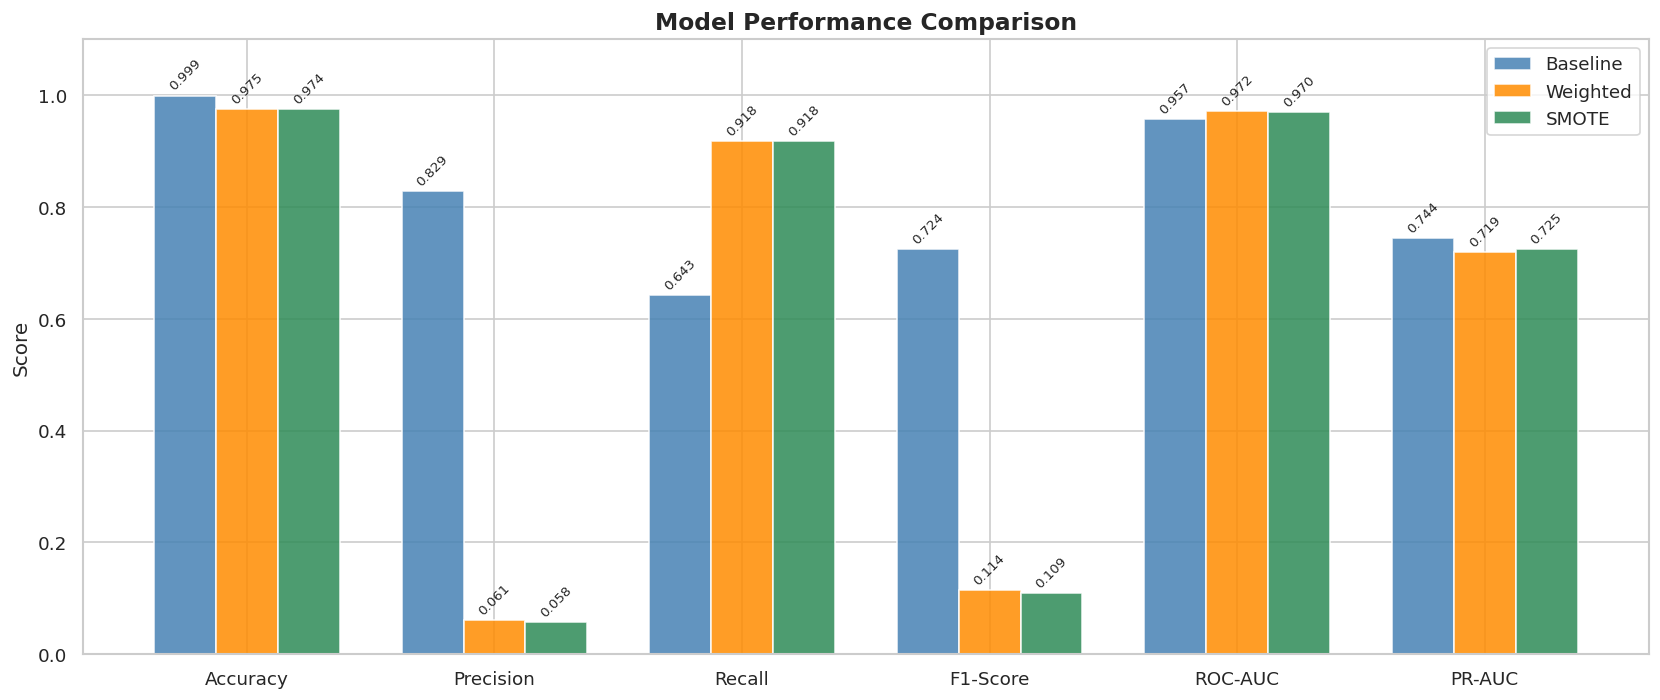

In [20]:
# ── Metrics Comparison Bar Chart ───────────────────────
metrics     = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
model_names = [r['name'].replace(' Logistic Regression','') for r in results]

data_matrix = [[r[m] for m in metrics] for r in results]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (row, name, col) in enumerate(zip(data_matrix, model_names, colors)):
    bars = ax.bar(x + i*width, row, width, label=name, color=col, alpha=0.85)
    for bar, val in zip(bars, row):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()